In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Импорт и обработка данных

Импортируй датафрейм *taxi_orders.csv* и исполни ячейки ниже, чтобы привести временные метки к нужному формату.

In [2]:
df = pd.read_csv('taxi_orders.csv')

In [3]:
df['order_dttm'] = pd.to_datetime(df['order_dttm'])
df['offer_dttm'] = pd.to_datetime(df['offer_dttm'])
df['assign_dttm'] = pd.to_datetime(df['assign_dttm'])
df['arrive_dttm'] = pd.to_datetime(df['arrive_dttm'])
df['trip_dttm'] = pd.to_datetime(df['trip_dttm'])

In [4]:
df.tail()

,id_order,id_client,lat,long,order_dttm,offer_dttm,assign_dttm,arrive_dttm,trip_dttm,label,flag_offer,flag_assign,flag_arrive,flag_trip
214570,ORD214571,CL38097,55.405143,37.902103,2025-03-31 23:21:07,2025-03-31 23:21:22,NaT,NaT,NaT,dmo,1,0,0,0
214571,ORD214572,CL45647,55.408913,37.894055,2025-03-31 23:21:13,2025-03-31 23:21:28,NaT,NaT,NaT,dmo,1,0,0,0
214572,ORD214573,CL20483,55.411061,37.904514,2025-03-31 23:09:00,NaT,NaT,NaT,NaT,dmo,0,0,0,0
214573,ORD214574,CL43563,55.418311,37.896651,2025-03-31 23:13:00,2025-03-31 23:13:14,NaT,NaT,NaT,dmo,1,0,0,0
214574,ORD214575,CL29727,55.409326,37.893884,2025-03-31 23:45:52,2025-03-31 23:46:07,2025-03-31 23:46:48,2025-03-31 23:56:48,2025-04-01 00:22:27,dmo,1,1,1,1


# Задание 1. Временная сегментация

## Визуализация основных метрик по дням

### **Подготовь необходимые группировки и переменные для визуализации**

In [5]:
metrics=['DST', 'AT', 'ETA', 'TT']
cols=['order_dttm', 'offer_dttm', 'assign_dttm', 'arrive_dttm', 'trip_dttm']

for i in range(4):
    df[metrics[i]]=(df[cols[i+1]]-df[cols[i]]).dt.seconds/60 #считаю временные метрики в  минутах, так как так удобнее

df['order_day']=df['order_dttm'].dt.day #создаю признак дня

In [6]:
data_days=pd.DataFrame()

#считаю все конверсии по дням месяца
data_days['convOrder2Offer']=df.groupby(df['order_day'])['flag_offer'].mean()
data_days['convOffer2Assign']=df[df['flag_offer']==1].groupby(df['order_day'])['flag_assign'].mean()
data_days['convAssign2Arrive']=df[df['flag_assign']==1].groupby(df['order_day'])['flag_arrive'].mean()
data_days['convArrive2Trip']=df[df['flag_arrive']==1].groupby(df['order_day'])['flag_trip'].mean()
data_days['convOrder2Trip']=df['flag_trip'].groupby(df['order_day']).mean()

for i in range(4):
    data_days[metrics[i]]=df.groupby(df['order_day'])[metrics[i]].mean()

### **Визуализируй конверсии по дням**

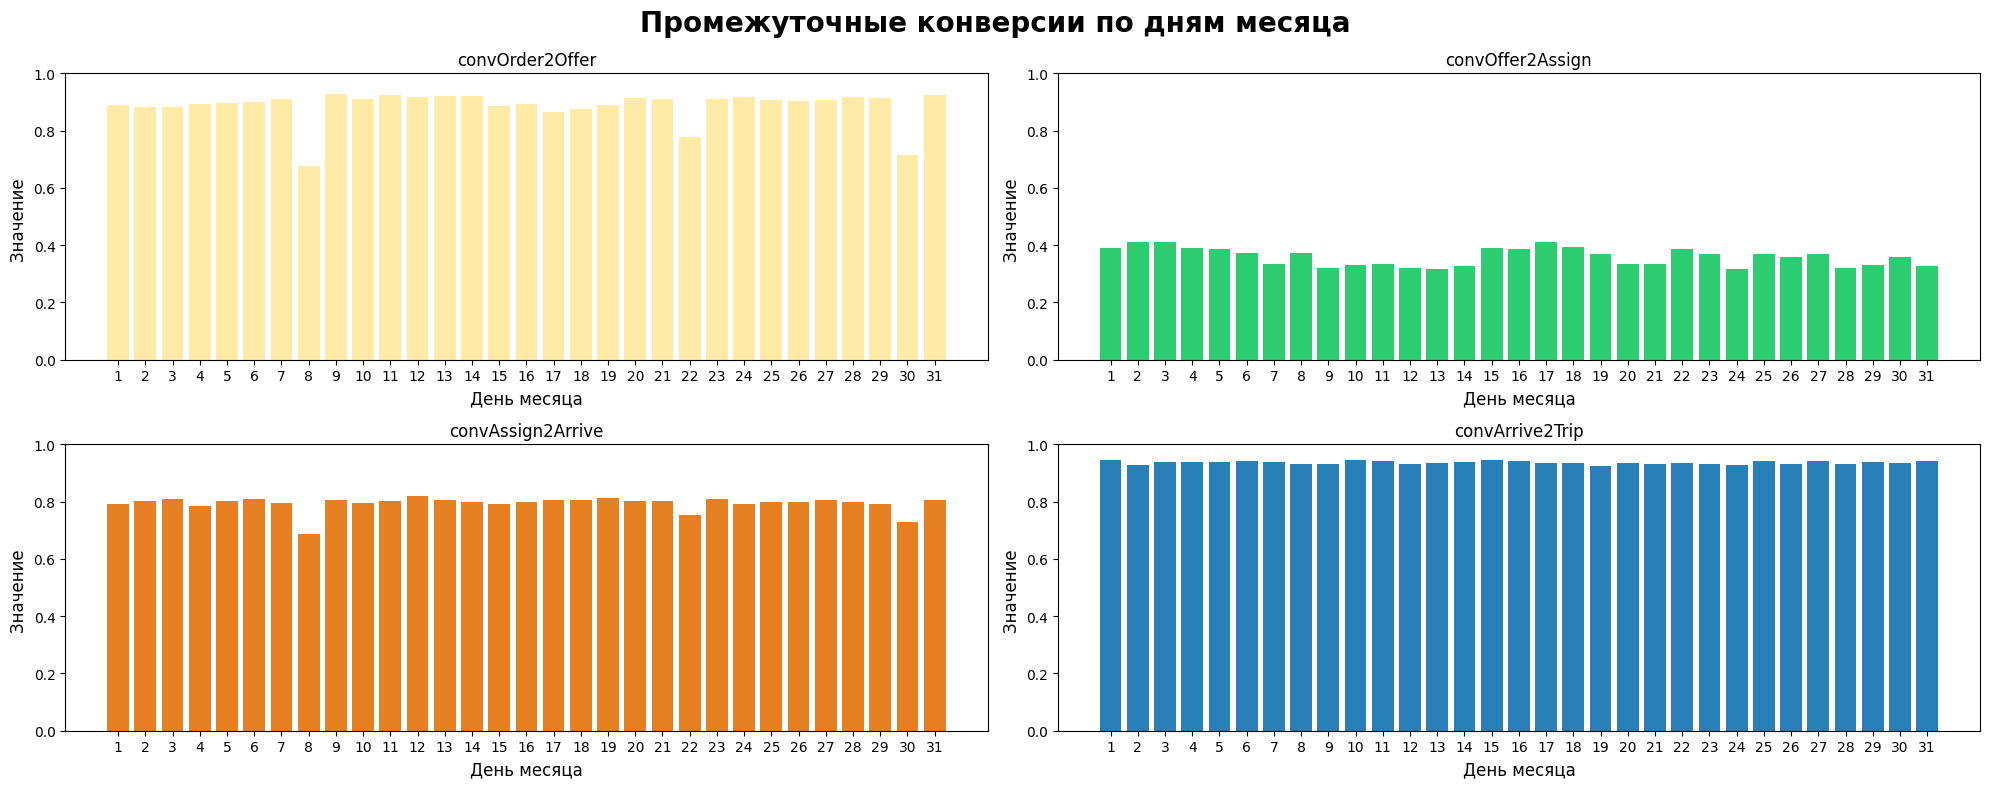

In [7]:
convs_1=['convOrder2Offer', 'convOffer2Assign', 'convAssign2Arrive', 'convArrive2Trip']
colors=['#FFEAA7', '#2ECC71', '#E67E22', '#2980B9']

fig, axes=plt.subplots(2, 2, figsize=(20, 8))
axes=axes.ravel()

for i in range(4):
    axes[i].set_title(convs_1[i])
    axes[i].bar(x=data_days.index, height=data_days[convs_1[i]], color=colors[i])
    axes[i].set_xlabel('День месяца', fontsize=12)
    axes[i].set_ylabel('Значение ', fontsize=12)
    axes[i].set_ylim(0, 1)
    axes[i].set_xticks(data_days.index)


plt.suptitle('Промежуточные конверсии по дням месяца', fontsize=20, fontweight='bold')
plt.tight_layout()

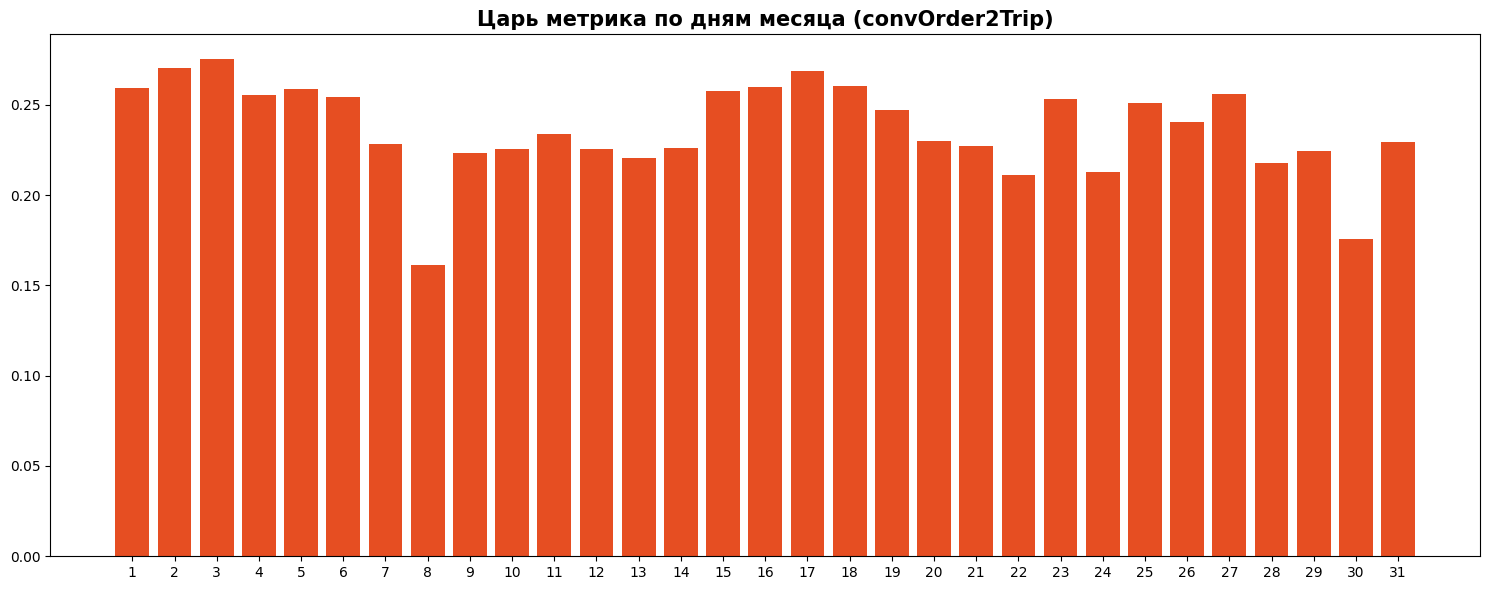

In [8]:
plt.figure(figsize=(15, 6))
plt.bar(x=data_days.index, height=data_days['convOrder2Trip'], color='#E64E22')
plt.title('Царь метрика по дням месяца (convOrder2Trip)', fontsize=15, fontweight='bold')
plt.xticks(data_days.index)
plt.tight_layout()

### **Визуализируй DST по дням**

### **Визуализируй Assign Time по дням**

### **Визуализируй ETA по дням**

### **Визуализируй Trip Time по дням**

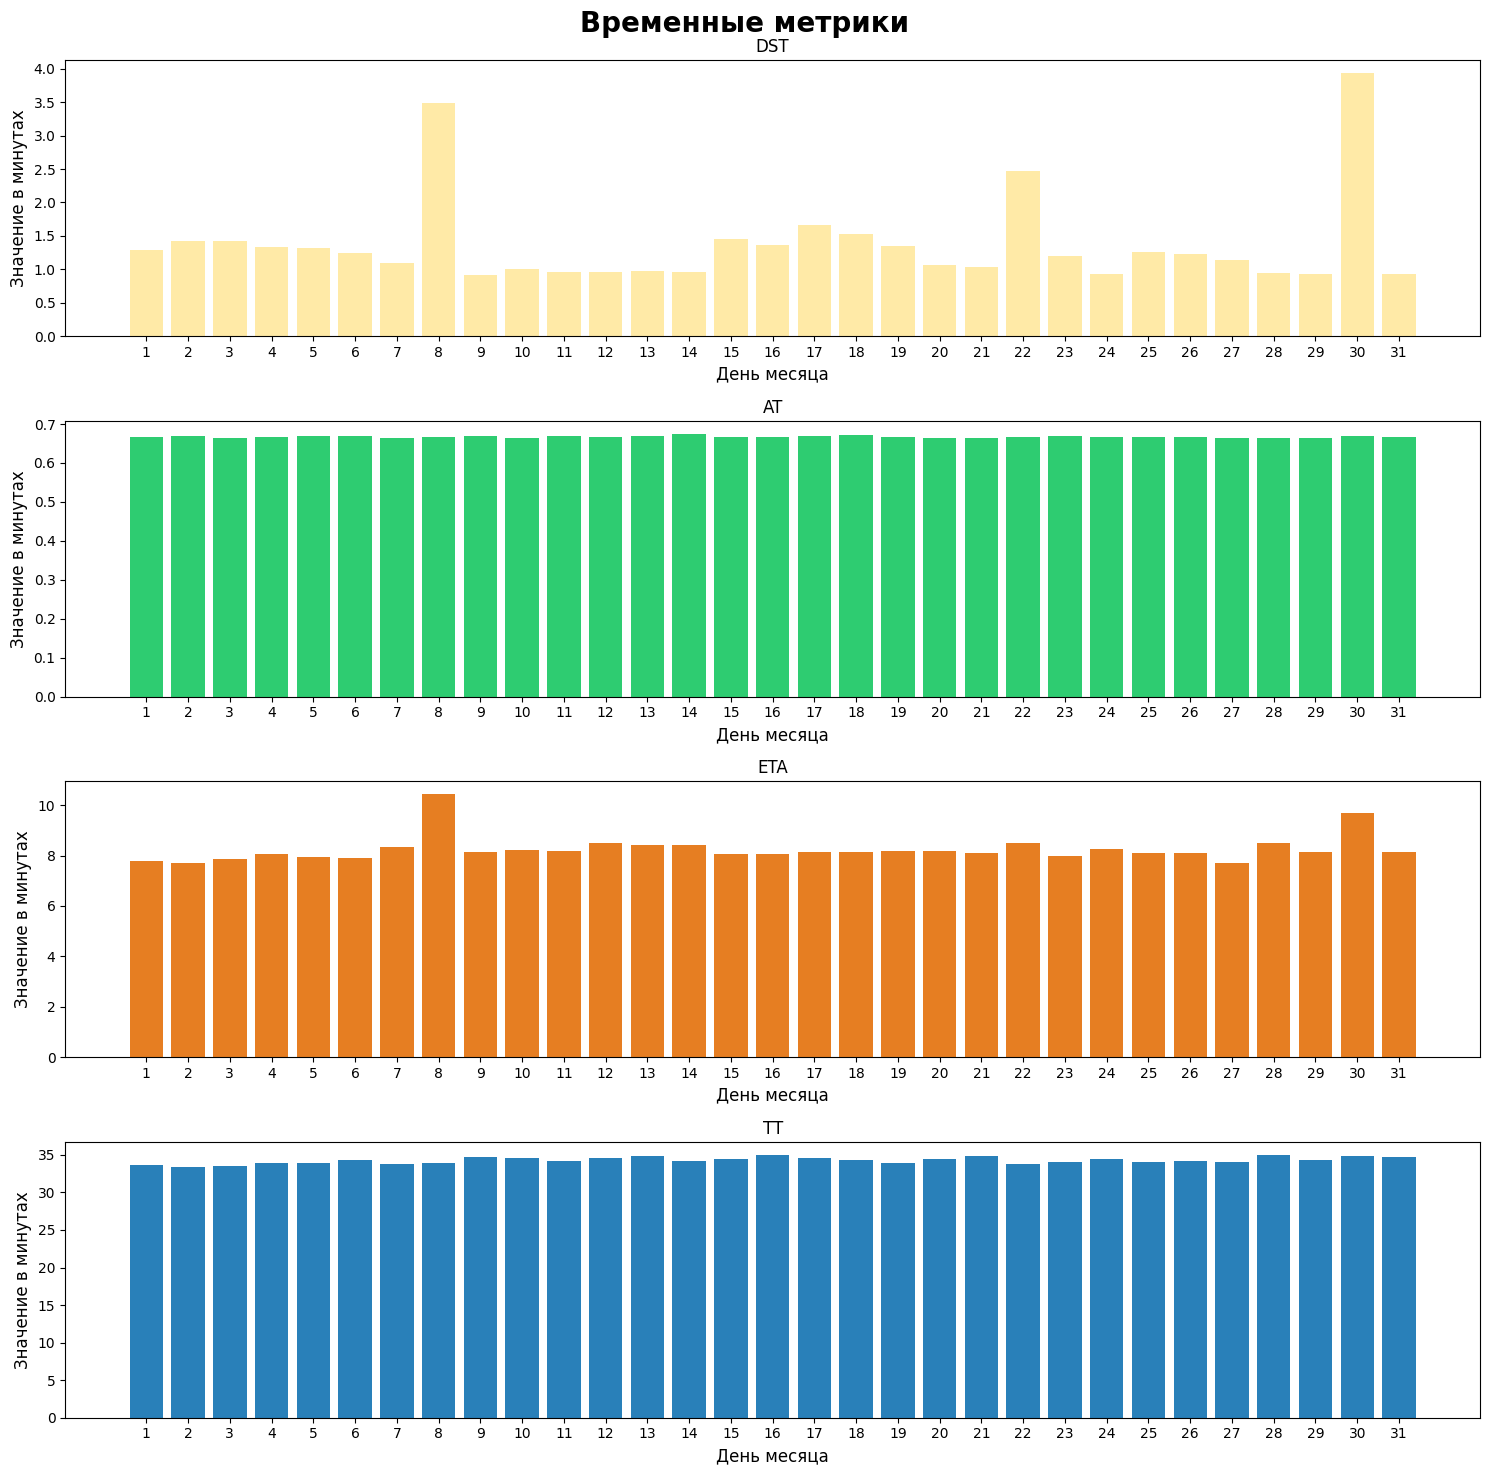

In [23]:
convs_2=['DST', 'AT', 'ETA', 'TT']
colors=['#FFEAA7', '#2ECC71', '#E67E22', '#2980B9']

fig, axes=plt.subplots(4, 1, figsize=(15, 15))
axes=axes.ravel()

for i in range(4):
    axes[i].set_title(convs_2[i])
    axes[i].bar(x=data_days.index, height=data_days[convs_2[i]], color=colors[i])
    axes[i].set_xlabel('День месяца', fontsize=12)
    axes[i].set_ylabel('Значение в минутах', fontsize=12)
    axes[i].set_xticks(data_days.index)


plt.suptitle('Временные метрики', fontsize=20, fontweight='bold')
plt.tight_layout()

## Визуализация по суточным часам

### **Подготовь необходимые группировки и переменные для визуализации**

In [15]:
df['order_hour']=df['order_dttm'].dt.hour

In [16]:
data_hours=pd.DataFrame()

data_hours['convOrder2Offer']=df.groupby(df['order_hour'])['flag_offer'].mean()
data_hours['convOffer2Assign']=df[df['flag_offer']==1].groupby(df['order_hour'])['flag_assign'].mean()
data_hours['convAssign2Arrive']=df[df['flag_assign']==1].groupby(df['order_hour'])['flag_arrive'].mean()
data_hours['convArrive2Trip']=df[df['flag_arrive']==1].groupby(df['order_hour'])['flag_trip'].mean()
data_hours['convOrder2Trip']=df['flag_trip'].groupby(df['order_hour']).mean()

for i in range(4):
    data_hours[metrics[i]]=df.groupby(df['order_hour'])[metrics[i]].mean()

### **Визуализируй конверсии по часам**

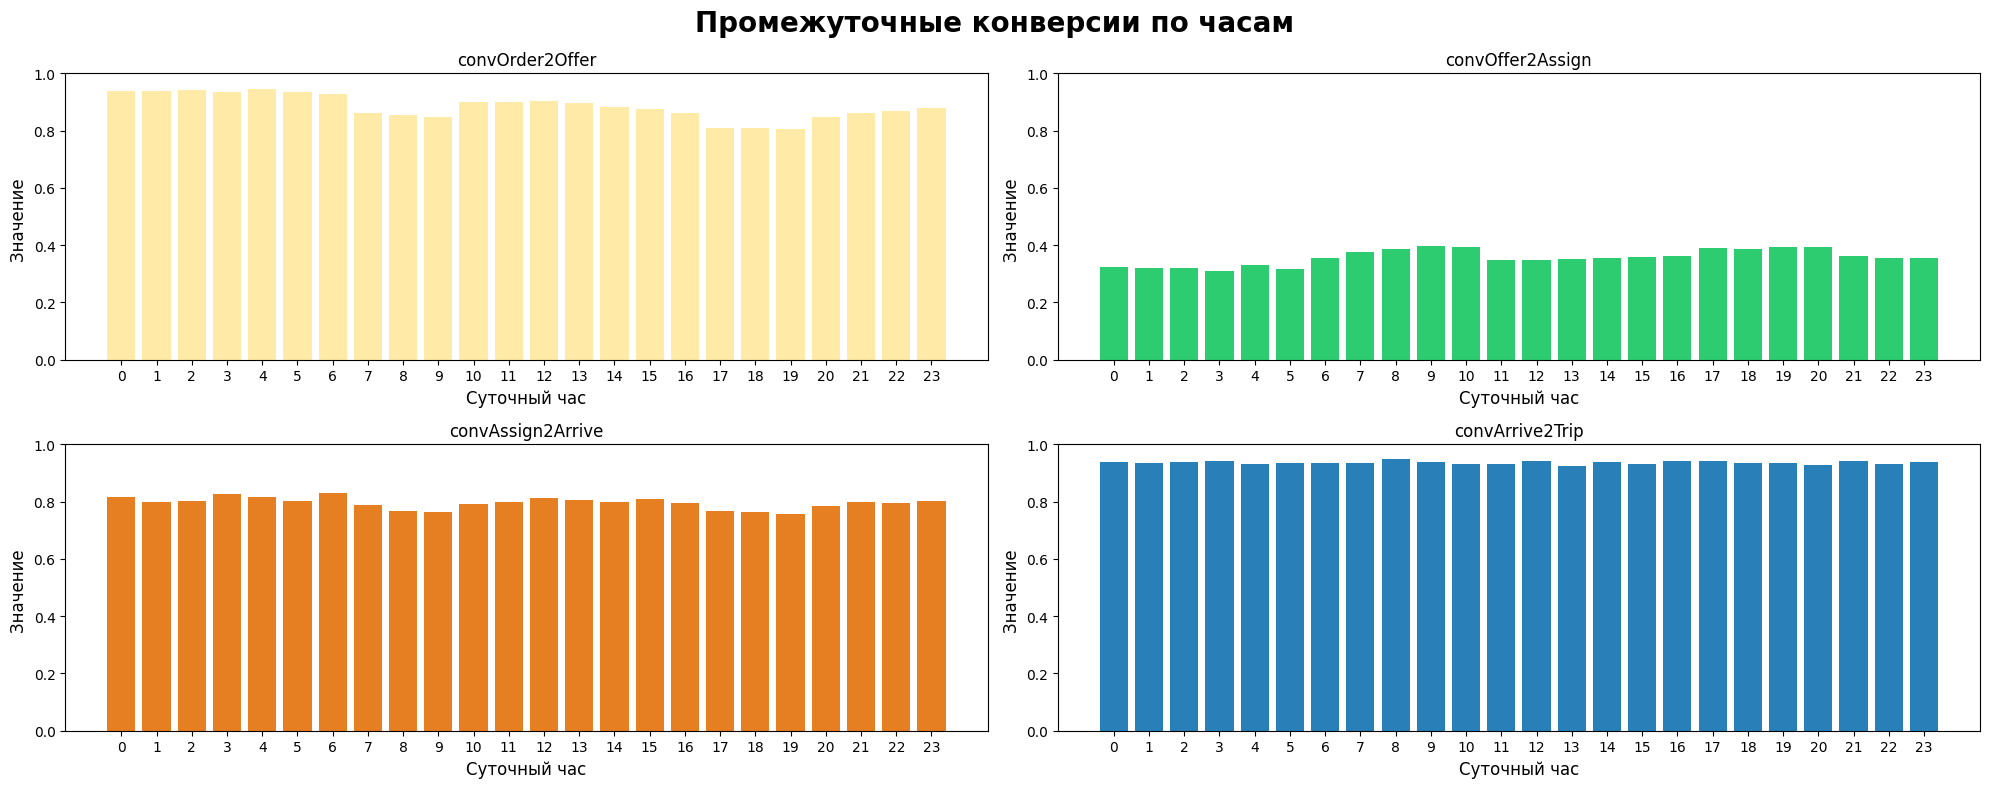

In [17]:
fig, axes=plt.subplots(2, 2, figsize=(20, 8))
axes=axes.ravel()

for i in range(4):
    axes[i].set_title(convs_1[i])
    axes[i].bar(x=data_hours.index, height=data_hours[convs_1[i]], color=colors[i])
    axes[i].set_xlabel('Суточный час', fontsize=12)
    axes[i].set_ylabel('Значение ', fontsize=12)
    axes[i].set_ylim(0, 1)
    axes[i].set_xticks(data_hours.index)


plt.suptitle('Промежуточные конверсии по часам', fontsize=20, fontweight='bold')
plt.tight_layout()

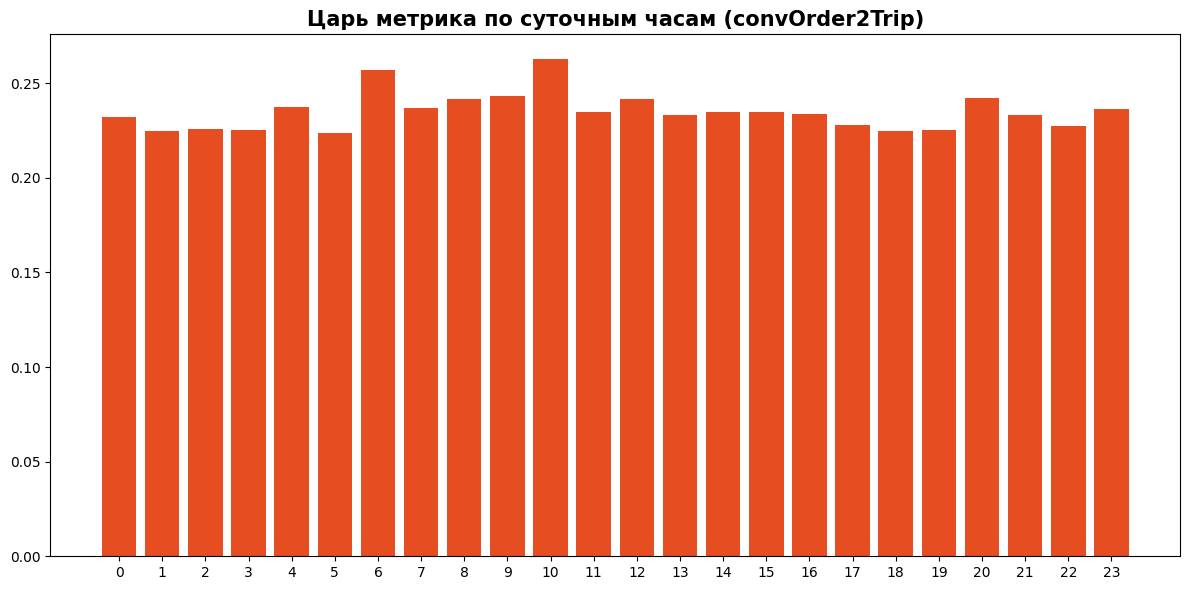

In [18]:
plt.figure(figsize=(12, 6))
plt.bar(x=data_hours.index, height=data_hours['convOrder2Trip'], color='#E64E22')
plt.title('Царь метрика по суточным часам (convOrder2Trip)', fontsize=15, fontweight='bold')
plt.xticks(data_hours.index)
plt.tight_layout()

### **Визуализируй DST по часам**

### **Визуализируй Assign Time по часам**

### **Визуализируй ETA по часам**

### **Визуализируй Trip Time по часам**

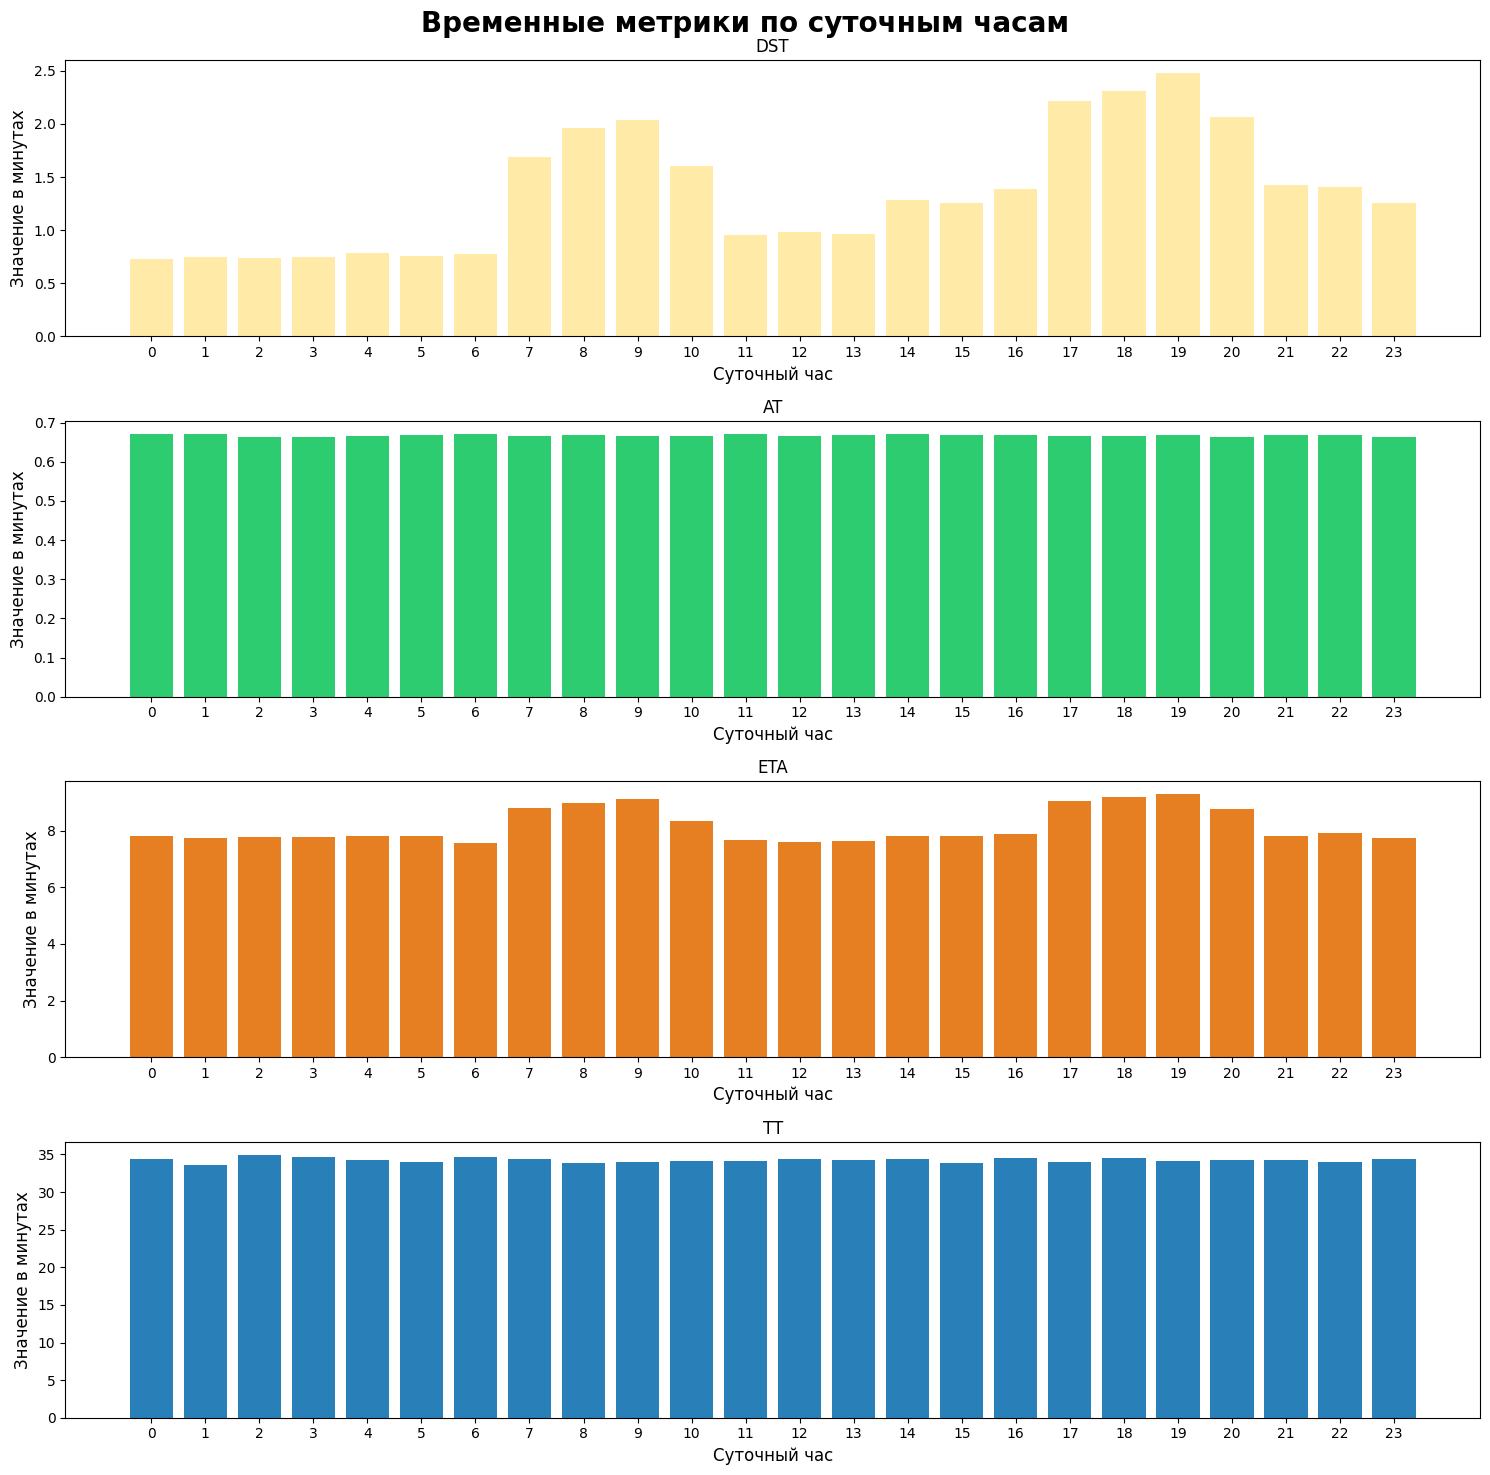

In [22]:
convs_2=['DST', 'AT', 'ETA', 'TT']
colors=['#FFEAA7', '#2ECC71', '#E67E22', '#2980B9']

fig, axes=plt.subplots(4, 1, figsize=(15, 15))
axes=axes.ravel()

for i in range(4):
    axes[i].set_title(convs_2[i])
    axes[i].bar(x=data_hours.index, height=data_hours[convs_2[i]], color=colors[i])
    axes[i].set_xlabel('Суточный час', fontsize=12)
    axes[i].set_ylabel('Значение в минутах', fontsize=12)
    axes[i].set_xticks(data_hours.index)


plt.suptitle('Временные метрики по суточным часам', fontsize=20, fontweight='bold')
plt.tight_layout()

## Статистическая значимость просадок

Дана функция, которая берёт на вход:

 - Две сравниваемые выборки;
 - Уровень значимости, который по умолчанию равен $5\%$. Менять его значение нет необходимости.

Функция рассчитывает статистическую значимость разности средних в двух выборках.

На выходе функция выдаёт True или False в зависимости от значимости разницы средних, а также "принтит" результаты.

С помощью данной функции необходимо оценить, были ли статистически значимые просадки метрик в моменты, которые в предыдущем задани были оценены как "проблемные".

In [20]:
from scipy import stats

def t_test_two_samples(sample1, sample2, alpha=0.05):

    t_stat, p_value = stats.ttest_ind(sample1, sample2, equal_var=False)

    if p_value < alpha:
        print(f"Статистически значимая разница есть (p-value: {p_value:.4f}, разница: {sample1.mean()-sample2.mean():.4f}, A: {sample1.mean():.4f}, B: {sample2.mean():.4f})")
        return True
    else:
        print(f"Статистически значимой разницы нет (p-value: {p_value:.4f}, разница: {sample1.mean()-sample2.mean():.4f}, A: {sample1.mean():.4f}, B: {sample2.mean():.4f})")
        return False

### Значимость ad hoc просадки

In [24]:
#Метрики конверсии по дням особенно просели 8, 23 и 30 марта, проверим статистическую значимость изменений метрик в этот день (только тех, по которым можно заметить какие-то аномалии)
df_adhoc=df[df['order_day']==8]
df_normal=df[df['order_day']!=8]

print('Проверяю царь-метрику: order-to-trip')
t_test_two_samples(df_adhoc['flag_trip'], df_normal['flag_trip'], alpha=0.05)
print('Проверяю order-to-offer')
t_test_two_samples(df_adhoc['flag_offer'], df_normal['flag_offer'], alpha=0.05)
print('Проверяю assign-to-arrive')
t_test_two_samples(df_adhoc[df_adhoc['flag_assign']==1]['flag_arrive'], df_normal[df_normal['flag_assign']==1]['flag_arrive'], alpha=0.05)

print('Проверяю DST')
t_test_two_samples(df_adhoc['DST'].dropna(), df_normal['DST'].dropna(), alpha=0.05)
print('Проверяю ETA')
t_test_two_samples(df_adhoc['ETA'].dropna(), df_normal['ETA'].dropna(), alpha=0.05)

Проверяю царь-метрику: order-to-trip
Статистически значимая разница есть (p-value: 0.0000, разница: -0.0783, A: 0.1610, B: 0.2394)
Проверяю order-to-offer
Статистически значимая разница есть (p-value: 0.0000, разница: -0.2124, A: 0.6754, B: 0.8878)
Проверяю assign-to-arrive
Статистически значимая разница есть (p-value: 0.0000, разница: -0.1097, A: 0.6867, B: 0.7964)
Проверяю DST
Статистически значимая разница есть (p-value: 0.0000, разница: 2.1384, A: 3.4839, B: 1.3455)
Проверяю ETA
Статистически значимая разница есть (p-value: 0.0000, разница: 2.2549, A: 10.4242, B: 8.1692)


True

### Значимость сезонной просадки

In [25]:
peak_hours=[7, 8, 9, 10, 17, 18, 19, 20] #аналогично проверяю только метрики, по которым видны какие-то просадки на графике

df_peakhours=df[df['order_hour'].isin(peak_hours)]
df_normal=df[~df['order_hour'].isin(peak_hours)]

print('Проверяю DST')
t_test_two_samples(df_peakhours['DST'].dropna(), df_normal['DST'].dropna(), alpha=0.05)
print('Проверяю ETA')
t_test_two_samples(df_peakhours['ETA'].dropna(), df_normal['ETA'].dropna(), alpha=0.05)

Проверяю DST
Статистически значимая разница есть (p-value: 0.0000, разница: 1.0249, A: 2.0583, B: 1.0334)
Проверяю ETA
Статистически значимая разница есть (p-value: 0.0000, разница: 1.2026, A: 8.9605, B: 7.7578)


True

## (Бонус) Факторный анализ количества поездок

$$Trips = Orders \cdot conv $$

Необходимо сравнить часы пик и обычные часы с точки зрения количества результирующих поездок и выручки.

 - Рассчитайте количество (среднечасовое, например) заказов в двух сегментах;
 - Рассчитайте конверсию из заказа в поездку в двух сегментах;
 - С помощью формул факторного анализа рассчитайте вклад двух мультипликативных факторов в модель;

In [27]:
count_orders_ph=df_peakhours['id_order'].count()/df_peakhours['order_hour'].nunique()
count_orders_norm=df_normal['id_order'].count()/df_normal['order_hour'].nunique()
conv_order2trip_ph=df_peakhours['flag_trip'].mean()
conv_order2trip_norm=df_normal['flag_trip'].mean()

count_trips_ph=df_peakhours['flag_trip'].sum()/df_peakhours['order_hour'].nunique()
count_trips_norm=df_normal['flag_trip'].sum()/df_normal['order_hour'].nunique()
trips_change=(count_trips_ph-count_trips_norm)

input_orders=conv_order2trip_norm*(count_orders_ph-count_orders_norm)
input_conv=count_orders_norm*(conv_order2trip_ph-conv_order2trip_norm)
input_together=(count_orders_ph-count_orders_norm)*(conv_order2trip_ph-conv_order2trip_norm)

res=round(trips_change-(input_orders+input_conv+input_together), 2)
print(res) #ура все сходится

0.0


In [46]:
print(count_orders_ph)
print(count_orders_norm)
print(conv_order2trip_ph*100)
print(conv_order2trip_norm*100)

10983.0
7919.4375
23.700264044432302
23.377607311125317


In [28]:
orders_perc=(input_orders/trips_change)*100
conv_perc=(input_conv/trips_change)*100
together_perc=(input_together/trips_change)*100

print(f'Вклад изменения количества заказов: {round(orders_perc, 2)}%')
print(f'Вклад изменения конверсии: {round(conv_perc, 2)}%')
print(f'Совместный вклад: {round(together_perc, 2)}%')

Вклад изменения количества заказов: 95.29%
Вклад изменения конверсии: 3.4%
Совместный вклад: 1.32%


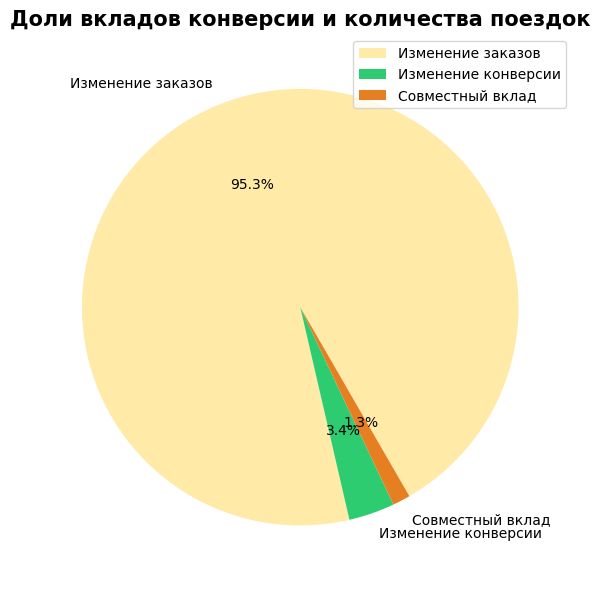

In [43]:
percs=[orders_perc, conv_perc, together_perc]
labels=['Изменение заказов', 'Изменение конверсии', 'Совместный вклад']
colors=['#FFEAA7', '#2ECC71', '#E67E22']

plt.figure(figsize=(10, 6))
plt.pie(percs, labels=labels, autopct='%1.1f%%', colors=colors, startangle=300)
plt.title('Доли вкладов конверсии и количества поездок', fontsize=15, fontweight='bold')
plt.legend(labels, loc='upper right')
plt.tight_layout()

# Задание 2. Гео сегментация

Напиши функцию, с помощью которой можно отфильтровать заказы, находящиеся в определенном радиусе относительно точки центра.

Аргументы функции:

 - *df_loc* - датафрейм, в котором должны быть поля *lat* и *long*
 - center lat и center_long - координаты центра окружности
 - radius_degrees - радиус (в градусах)

Функция возвращает отфильтрованный датафрейм, в котором остаются только строки, координаты которых попадают в круг.

Для расчёта расстояния между точками $(x_0, y_0)$ и $(x_1, y_1)$ воспользуйся формулой:

$$d = \sqrt{(x_0-x_1)^2+(y_0-y_1)^2}$$

In [51]:
def filter_location(df_loc, center_lat, center_long, radius_degrees):
  return df[np.sqrt((center_lat-df['lat'])**2+(center_long-df['long'])**2)<=radius_degrees]

Даны координаты специальных зон и значения их радиусов.

In [52]:
### Аэропорты
VKO_CENTER = (55.5915, 37.2613)
SVO_CENTER = (55.9726, 37.4146)
DME_CENTER = (55.4143, 37.9005)
ZONE_RADIUS_AER = 0.025

In [53]:
### Зеленоград
ZELENOGRAD_CENTER = (55.9825, 37.1814)
ZONE_RADIUS_ZEL = 0.045

In [54]:
### Ажиотажные зоны
VDNH_CENTER = (55.8251, 37.6387)
GORKY_PARK_CENTER = (55.7280, 37.5987)
SPECIAL_ZONE_RADIUS = 0.015

## Разметка специальных зон и событий

1. Создай в датафрейме столбец zone. Разметь в нём три уникальных значения:
 - *zelenograd* - Зеленоград;
 - *airports* - все три аэпорта вместе;
 - *regular* - остальные заказы;

2. Создай в датафрейме столбец special_event. Разметь в нём три уникальных значения:
 - *vdnh* - ВДНХ (только в ажиотажные часы 22.03 с 16 до 22);
 - *pg* - Парк Горького (только в ажиотажные часы 30.03 с 14 до 23);
 - *regular* - остальные заказы;

In [55]:
airports=[VKO_CENTER, SVO_CENTER, DME_CENTER]

def location(row):
  for i in range(3):
    if np.sqrt((airports[i][0]-row['lat'])**2+(airports[i][1]-row['long'])**2)<=ZONE_RADIUS_AER:
      return 'airports'
  if np.sqrt((ZELENOGRAD_CENTER[0]-row['lat'])**2+(ZELENOGRAD_CENTER[1]-row['long'])**2)<=ZONE_RADIUS_ZEL:
    return 'zelenograd'
  else:
    return 'regular'


df['zone']=df.apply(location, axis=1)

In [56]:
def event(row):
  if (row['order_day']==22) and (16<=row['order_hour']<=22):
    return'vdnh'
  elif (row['order_day']==30) and (14<=row['order_hour']<=23):
    return 'pg'
  else:
    return 'regular'

df['special_event']=df.apply(event, axis=1)

## Визуализация метрик по зонам

### Визуализируй конверсии по дням в разбивке по зонам

Построй график конверсий в разбивке по зонам:
- Order2Trip
- Order2Offer
- Offer2Assign
- Assign2Arrive
- Arrive2Trip

Сделай выводы о работе воронки в особых зонах.

In [57]:
data_regions=pd.DataFrame()

data_regions=df.groupby([df['zone'], df['order_day']])['flag_offer'].mean().reset_index(name='convOrder2Offer')
convOffer2Assign=df[df['flag_offer']==1].groupby([df['zone'], df['order_day']])['flag_assign'].mean().reset_index(name='convOffer2Assign')
convAssign2Arrive=df[df['flag_assign']==1].groupby([df['zone'], df['order_day']])['flag_arrive'].mean().reset_index(name='convAssign2Arrive')
convArrive2Trip=df[df['flag_arrive']==1].groupby([df['zone'], df['order_day']])['flag_trip'].mean().reset_index(name='convArrive2Trip')
convOrder2Trip=df['flag_trip'].groupby([df['zone'], df['order_day']]).mean().reset_index(name='convOrder2Trip')

DST=df.groupby([df['zone'], df['order_day']])['DST'].mean().reset_index(name='DST')
AT=df.groupby([df['zone'], df['order_day']])['AT'].mean().reset_index(name='AT')
ETA=df.groupby([df['zone'], df['order_day']])['ETA'].mean().reset_index(name='ETA')

data_regions=data_regions.merge(convOffer2Assign, on=['zone', 'order_day'], how='left')
data_regions=data_regions.merge(convAssign2Arrive, on=['zone', 'order_day'], how='left')
data_regions=data_regions.merge(convArrive2Trip, on=['zone', 'order_day'], how='left')
data_regions=data_regions.merge(convOrder2Trip, on=['zone', 'order_day'], how='left')
data_regions=data_regions.merge(ETA, on=['zone', 'order_day'], how='left')
data_regions=data_regions.merge(AT, on=['zone', 'order_day'], how='left')
data_regions=data_regions.merge(DST, on=['zone', 'order_day'], how='left')

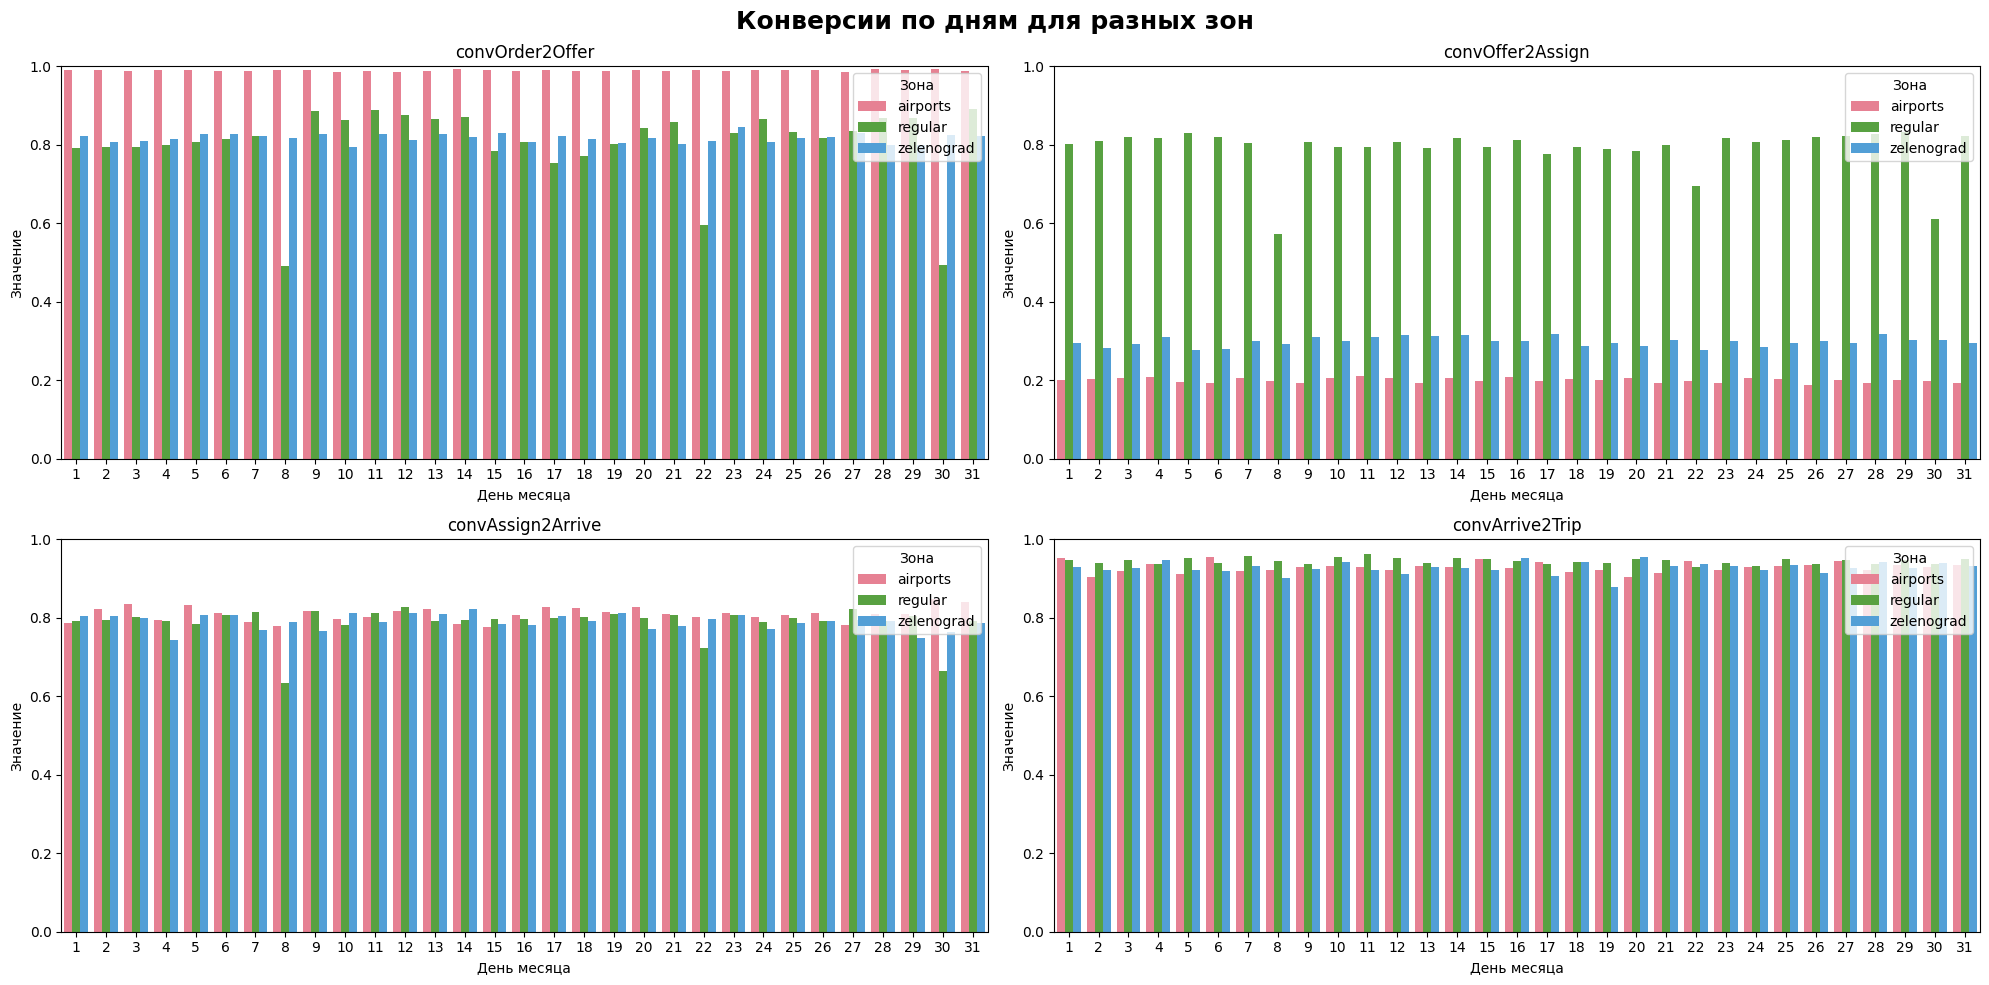

In [58]:
convs=['convOrder2Offer', 'convOffer2Assign', 'convAssign2Arrive', 'convArrive2Trip']

fig, axes=plt.subplots(2, 2, figsize=(20, 10))
axes=axes.ravel()

fig.suptitle('Конверсии по дням для разных зон', fontweight='bold', fontsize=18)

for i in range(4):
    axes[i].set_title(convs[i])
    sns.barplot(data=data_regions, x='order_day', y=convs[i], width=0.8, hue='zone', ax=axes[i], palette='husl')
    axes[i].set_xlabel('День месяца')
    axes[i].set_ylabel('Значение')
    axes[i].set_ylim(0, 1)
    axes[i].legend(title='Зона', loc='upper right')

plt.tight_layout()
plt.show()

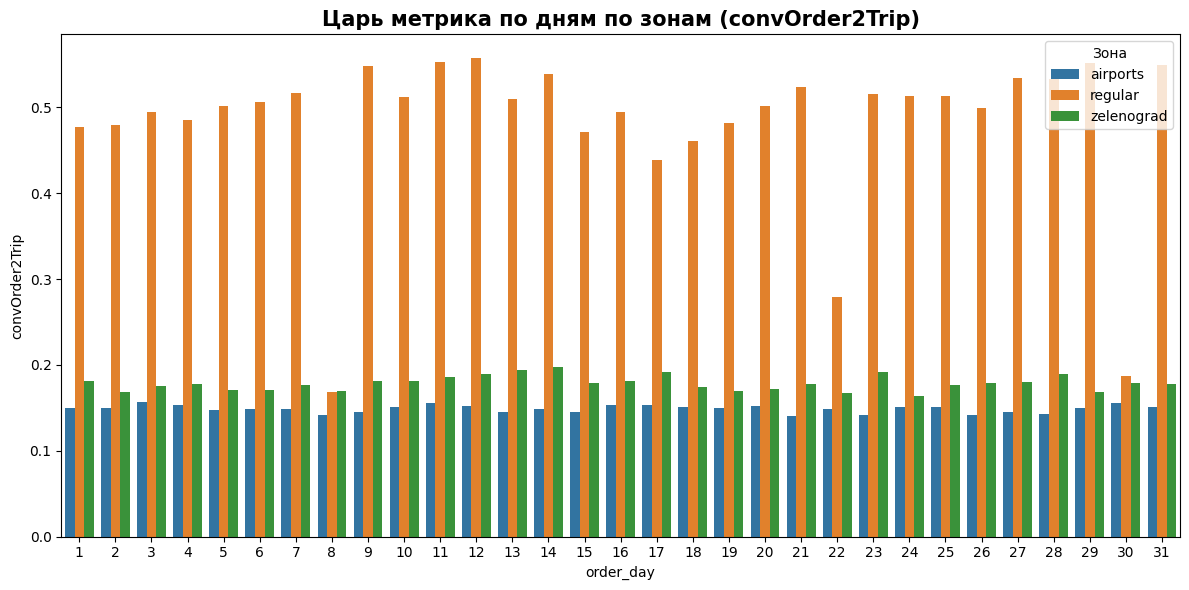

In [59]:
plt.figure(figsize=(12, 6))
sns.barplot(data_regions, x='order_day', y='convOrder2Trip', hue='zone', palette='tab10')
plt.title('Царь метрика по дням по зонам (convOrder2Trip)', fontsize=15, fontweight='bold')
plt.legend(title='Зона', loc='upper right')
plt.tight_layout()

### Визуализируй временные метрики по дням в разбивке по зонам

Построй временные метрики в разбивке по зонам:
- DST
- Assign Time
- ETA

Сделай выводы о работе воронки в особых зонах

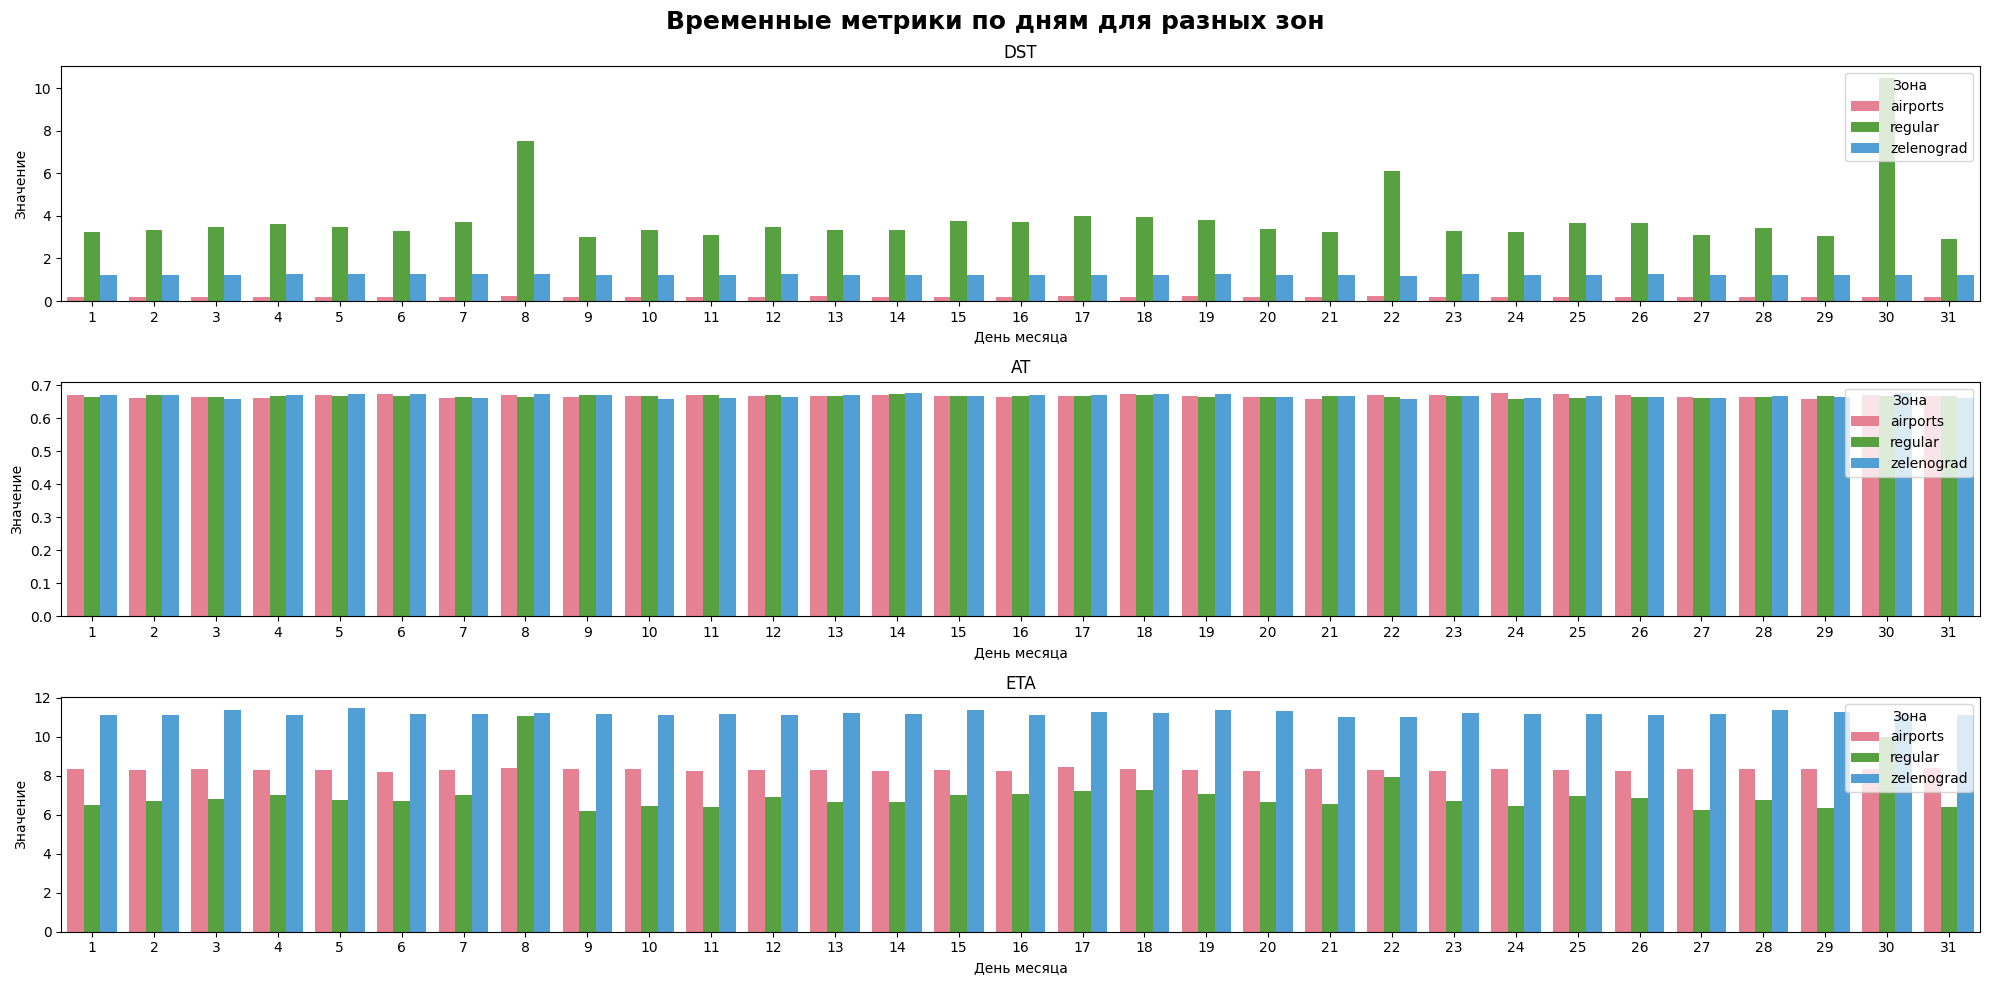

In [60]:
convs=['DST', 'AT', 'ETA']

fig, axes=plt.subplots(3, 1, figsize=(20, 10))

fig.suptitle('Временные метрики по дням для разных зон', fontweight='bold', fontsize=18)

for i in range(3):
    axes[i].set_title(convs[i])
    sns.barplot(data=data_regions, x='order_day', y=convs[i], width=0.8, hue='zone', ax=axes[i], palette='husl')
    axes[i].set_xlabel('День месяца')
    axes[i].set_ylabel('Значение')
    axes[i].legend(title='Зона', loc='upper right')

plt.tight_layout()
plt.show()


## Влияние событий ажиотажа

Рассчитай значения всех метрик в зонах и временных интервалах ожиотажа (ВДНХ и Парк Горького).

Рассчитай статистическую значимость просадок.

### Рассчитай средние значения метрик для зон ажиотажа

In [61]:
data=pd.DataFrame()

In [62]:
data['convOrder2Offer']=df.groupby(df['special_event'])['flag_offer'].mean()
data['convOffer2Assign']=df[df['flag_offer']==1].groupby(df['special_event'])['flag_assign'].mean()
data['convAssign2Arrive']=df[df['flag_assign']==1].groupby(df['special_event'])['flag_arrive'].mean()
data['convArrive2Trip']=df[df['flag_arrive']==1].groupby(df['special_event'])['flag_trip'].mean()
data['convOrder2Trip']=df['flag_trip'].groupby(df['special_event']).mean()

data['DST']=df.groupby(df['special_event'])['DST'].mean()
data['AT']=df.groupby(df['special_event'])['AT'].mean()
data['ETA']=df.groupby(df['special_event'])['ETA'].mean()
data['TT']=df.groupby(df['special_event'])['TT'].mean()

In [63]:
data

,convOrder2Offer,convOffer2Assign,convAssign2Arrive,convArrive2Trip,convOrder2Trip,DST,AT,ETA,TT
special_event,,,,,,,,,
pg,0.605105,0.400254,0.678730,0.932647,0.153314,6.282732,0.668265,10.587590,34.863708
regular,0.889733,0.360223,0.796171,0.936608,0.238998,1.285097,0.667237,8.187305,34.236908
vdnh,0.649223,0.421331,0.695906,0.919568,0.175046,4.314719,0.663395,9.414106,33.641667


In [68]:
data.to_excel('таблица.xlsx') #чтобы импортировать таблицу в презентацию

### Определи стат.значимость изменений метрик во время ажиотажа

In [123]:
df_se=df[(df['special_event']=='pg') | (df['special_event']=='vdnh')]
df_reg=df[df['special_event']=='regular']

In [124]:
for i in convs_2:
  print(i)
  t_test_two_samples(df_se.dropna()[i], df_reg.dropna()[i], alpha=0.05)

DST
Статистически значимая разница есть (p-value: 0.0000, разница: 3.7196, A: 5.6208, B: 1.9012)
AT
Статистически значимой разницы нет (p-value: 0.1740, разница: -0.0033, A: 0.6638, B: 0.6671)
ETA
Статистически значимая разница есть (p-value: 0.0000, разница: 1.9116, A: 10.0843, B: 8.1727)
TT
Статистически значимой разницы нет (p-value: 0.7971, разница: 0.0958, A: 34.3327, B: 34.2369)


In [129]:
t_test_two_samples(df_se['flag_offer'], df_reg['flag_offer'], alpha=0.05)
t_test_two_samples(df_se[df_se['flag_offer']==1]['flag_assign'], df_reg[df_reg['flag_offer']==1]['flag_assign'], alpha=0.05)
t_test_two_samples(df_se[df_se['flag_assign']==1]['flag_arrive'], df_reg[df_reg['flag_assign']==1]['flag_arrive'], alpha=0.05)
t_test_two_samples(df_se[df_se['flag_arrive']==1]['flag_trip'], df_reg[df_reg['flag_arrive']==1]['flag_trip'], alpha=0.05)
t_test_two_samples(df_se['flag_trip'], df_reg['flag_trip'], alpha=0.05)

Статистически значимая разница есть (p-value: 0.0000, разница: -0.2669, A: 0.6229, B: 0.8897)
Статистически значимая разница есть (p-value: 0.0000, разница: 0.0489, A: 0.4091, B: 0.3602)
Статистически значимая разница есть (p-value: 0.0000, разница: -0.1100, A: 0.6861, B: 0.7962)
Статистически значимой разницы нет (p-value: 0.1103, разница: -0.0097, A: 0.9269, B: 0.9366)
Статистически значимая разница есть (p-value: 0.0000, разница: -0.0769, A: 0.1621, B: 0.2390)


True

## (Бонус) Влияние погоды

Воспользуйся кодом ниже, чтобы подключиться по API к архиву погоды и загрузить в датафрейм данные о дневной температуре.

Исследуй зависимость между погодой и значениями метрик.

In [ ]:
import requests

url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    'latitude': 59.94,
    'longitude': 30.31,
    'start_date': '2024-03-01',
    'end_date': '2024-03-31',
    'daily': 'temperature_2m_max',
    'timezone': 'Europe/Moscow'
}

response = requests.get(url, params=params)
data = response.json()

temperatures = {}
for i, date in enumerate(data['daily']['time']):
    temp = data['daily']['temperature_2m_max'][i]
    temperatures[date] = temp

In [ ]:
print(type(temperatures))
print(temperatures['2024-03-01'])

<class 'dict'>
2.2


In [ ]:
##########################################################################################
##########################################################################################
##########################################################################################
##########################################################################################
##########################################################################################
##########################################################################################
##########################################################################################
##########################################################################################